# Binance 暴涨币因子：严格历史验证与纸面可行性

本 notebook 是版本化证据包的可运行伴侣。它不重新选因子、不连接订单模块，只读取分析脚本产生的冻结结果。

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
summary = json.loads((ROOT / 'analysis_summary.json').read_text(encoding='utf-8'))
folds = pd.read_csv(ROOT / 'walk_forward_fold_metrics.csv')
surface = pd.read_csv(ROOT / 'threshold_horizon_surface.csv')
oi_folds = pd.read_csv(ROOT / 'oi_walk_forward_fold_metrics.csv')
paper = pd.read_csv(ROOT / 'paper_strategy_summary.csv')
summary['validation_label'], len(folds), len(surface)

('historical_walk_forward_not_untouched_oos', 7, 28)

## TL;DR 与方法

主标签在每日 08:20 Asia/Shanghai 计算后，于下一根 4h 开盘（UTC 04:00）进入，未来 14 天最高价达到 +200%。验证采用至少 180 天训练、14 天 purge、30 天测试的扩展窗口。所有历史结果均称为 historical walk-forward；真正 OOS 只来自每日冻结监控。

In [2]:
metric = summary['price_validation']['historical_walk_forward']
boot = summary['price_validation']['lift_bootstrap_7d_blocks']
pd.Series({
    'AUC': metric['auc'],
    'Top-2% precision': metric['top_2pct_precision'],
    'Top-2% lift': metric['top_2pct_lift'],
    'Lift CI low': boot['lower_95pct'],
    'Lift CI high': boot['upper_95pct'],
    'Independent event capture': summary['price_validation']['event_capture_rate'],
})

AUC                           0.763245
Top-2% precision              0.094025
Top-2% lift                   8.935384
Lift CI low                   7.041561
Lift CI high                 10.522367
Independent event capture     0.393939
dtype: float64

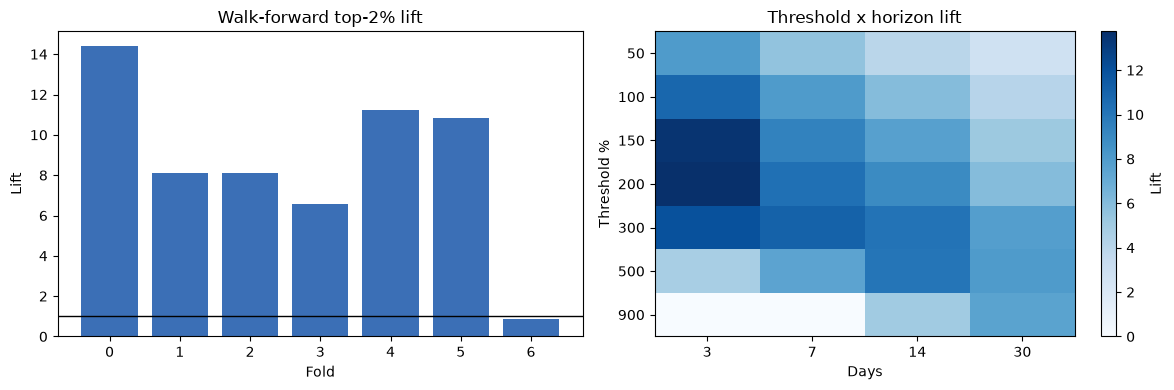

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(folds['fold'].astype(str), folds['price_top_2pct_lift'], color='#3B6FB6')
axes[0].axhline(1, color='black', lw=1)
axes[0].set(title='Walk-forward top-2% lift', xlabel='Fold', ylabel='Lift')
pivot = surface.pivot(index='threshold_pct', columns='horizon_days', values='lift')
im = axes[1].imshow(pivot, aspect='auto', cmap='Blues')
axes[1].set_xticks(range(len(pivot.columns)), pivot.columns)
axes[1].set_yticks(range(len(pivot.index)), pivot.index)
axes[1].set(title='Threshold x horizon lift', xlabel='Days', ylabel='Threshold %')
fig.colorbar(im, ax=axes[1], label='Lift')
plt.tight_layout(); plt.show()

## OI 与交易门槛

价格-only、OI-only、价格+OI 只在完全相同交集行上比较。OI 必须在多数折同时提高 AP 与 top-2% lift，且两项增量置信区间下界均大于 0，才能进入排名。交易模拟含 4h 路径、保守同 K 线退出、资金费率、手续费、滑点、仓位与组合约束。

In [4]:
display(pd.DataFrame([summary['oi_validation']]).drop(columns=['bootstrap', 'rule']))
display(paper.sort_values(['slippage_bps_each_side', 'expectancy'], ascending=[True, False]).head(12))
summary['paper_strategy']

,ranking_eligible,folds,fold_majority_both_positive,factor_group_evidence
0,False,5,0.2,{'small_cap': {'fold_majority_ap_and_lift_posi...


,trades,expectancy,median_return,win_rate,profit_factor,cvar_5pct,mean_mfe,mean_mae,funding_coverage,total_return_on_initial_equity,...,market_states,market_state_majority_profit_factor_gt_1,largest_positive_pnl_share,leave_largest_winner_out_expectancy,median_notional_usd,maximum_concurrent_positions_constraint,maximum_gross_exposure_constraint,gate_pass,policy,slippage_bps_each_side
9,238,0.050862,-0.201400,0.327731,1.386014,-0.213557,0.455016,-0.194084,0.289916,0.328109,...,7,0.714286,0.047727,0.042647,2792.473669,10,0.5,True,stop20_half_at100_trail25_time30,5.0
6,238,0.049958,-0.201400,0.327731,1.379148,-0.213557,0.455016,-0.194084,0.289916,0.319168,...,7,0.714286,0.070236,0.037583,2781.855094,10,0.5,True,stop20_trail25_after50_time30,5.0
3,228,0.041002,-0.201400,0.232456,1.293167,-0.216770,0.602160,-0.208446,0.293860,0.212455,...,7,0.428571,0.183747,0.009025,2604.931682,10,0.5,False,stop20_time14,5.0
0,130,0.016680,-0.123860,0.369231,1.083902,-0.800389,0.668947,-0.347231,0.323077,0.037397,...,6,0.333333,0.138067,-0.012614,2500.000000,10,0.5,False,hold_14d,5.0
4,225,0.050432,-0.202200,0.240000,1.362769,-0.217348,0.616112,-0.207313,0.297778,0.268569,...,7,0.571429,0.179505,0.018142,2601.901077,10,0.5,False,stop20_time14,15.0
10,240,0.049079,-0.202200,0.329167,1.370796,-0.220027,0.454126,-0.193564,0.295833,0.317271,...,7,0.714286,0.047436,0.040944,2786.560701,10,0.5,True,stop20_half_at100_trail25_time30,15.0
7,240,0.048056,-0.202200,0.329167,1.363068,-0.220027,0.454126,-0.193564,0.295833,0.307391,...,7,0.714286,0.069857,0.035808,2770.668015,10,0.5,True,stop20_trail25_after50_time30,15.0
1,130,0.014684,-0.125613,0.369231,1.073550,-0.800826,0.667281,-0.347883,0.323077,0.030751,...,6,0.333333,0.138852,-0.014551,2496.456660,10,0.5,False,hold_14d,15.0
5,225,0.048096,-0.203400,0.240000,1.343321,-0.218548,0.613695,-0.207513,0.297778,0.253260,...,7,0.428571,0.179558,0.015907,2584.789886,10,0.5,False,stop20_time14,30.0
11,242,0.041211,-0.203400,0.322314,1.306456,-0.217651,0.446228,-0.195443,0.289256,0.261801,...,7,0.714286,0.047586,0.033141,2757.706247,10,0.5,True,stop20_half_at100_trail25_time30,30.0


{'paper_trade_candidate': True,
 'best_policy': 'stop20_half_at100_trail25_time30',
 'best_policy_expectancy': 0.05086245673891571,
 'best_policy_profit_factor': 1.3860140741806466,
 'best_policy_max_drawdown': -0.10164343040583812,
 'final_classification': 'paper_trade_candidate'}

## Takeaways

1. 价格脆弱度/波动结构能在历史 walk-forward 中提高 +200% 事件浓度，但跨折差异必须保留。
2. OI 是否有独立增量只按预注册门槛裁决；未通过时只能作拥挤度或数据质量注释。
3. 纸面策略只有同时通过成本后期望、利润因子、回撤、跨折/市场状态和利润集中度门槛才可称候选；否则维持观察名单。
4. 历史下架合约恢复仍是覆盖缺口；每日监控的 30/60/90 天冻结复盘才是真正 OOS。

## Multisource extension: news, on-chain and exchange evidence
This section reads only the independently verified output files. News uses fetched-time availability; TVL is lagged one day.


In [5]:
from pathlib import Path
import json, pandas as pd
report = Path('.')
multisource = json.loads((report / 'multisource_analysis_summary.json').read_text(encoding='utf-8'))
news_folds = pd.read_csv(report / 'multisource_news_fold_metrics.csv')
onchain_folds = pd.read_csv(report / 'multisource_onchain_fold_metrics.csv')
catalyst_trades = pd.read_csv(report / 'multisource_catalyst_strategy_trades.csv.gz')
multisource['strict_strategy_decision'], news_folds, onchain_folds, catalyst_trades.head()


({'new_family_ranking_eligible': False,
  'auto_trade_eligible': False,
  'classification': 'watchlist_only',
  'reason': 'a family must pass same-row incremental gates before any entry rule is sent to the frozen 4h exit and portfolio simulator'},
   family  fold                train_start                  train_end  \
 0   news     4  2026-03-01 00:00:00+00:00  2026-04-08 00:00:00+00:00   
 1   news     5  2026-03-01 00:00:00+00:00  2026-05-08 00:00:00+00:00   
 2   news     6  2026-03-01 00:00:00+00:00  2026-06-07 00:00:00+00:00   
 
                   test_start                   test_end  train_rows  \
 0  2026-04-23 00:00:00+00:00  2026-05-22 00:00:00+00:00       19587   
 1  2026-05-23 00:00:00+00:00  2026-06-21 00:00:00+00:00       34868   
 2  2026-06-22 00:00:00+00:00  2026-07-04 00:00:00+00:00       50304   
 
    train_positives  test_rows  test_positives  ...  combo_n  combo_positives  \
 0              245      15358             146  ...    15358              146   
 1    

## Entry and exit timing extension

This section reads the time-isolated entry catalog, one-bar microstructure model, rank-threshold sensitivity, risk-equal stop study, and 4h path timing diagnostics. Rule selection uses only outcomes matured before fold 3; folds 3-6 remain historical confirmation, not true future OOS.

In [6]:
timing = json.loads((ROOT / 'entry_exit_timing_decision.json').read_text(encoding='utf-8'))
micro = json.loads((ROOT / 'microstructure_confirmation_decision.json').read_text(encoding='utf-8'))
rank = json.loads((ROOT / 'rank_threshold_decision.json').read_text(encoding='utf-8'))
path_timing = json.loads((ROOT / 'path_timing_decision.json').read_text(encoding='utf-8'))
stops = json.loads((ROOT / 'stop_width_decision.json').read_text(encoding='utf-8'))
entry_rules = pd.read_csv(ROOT / 'entry_timing_calibration.csv')
rank_confirmation = pd.read_csv(ROOT / 'rank_threshold_confirmation.csv')
stop_confirmation = pd.read_csv(ROOT / 'stop_width_confirmation.csv')
path_summary = pd.read_csv(ROOT / 'path_timing_summary.csv')
pd.Series({
    'selected entry': timing['selected_entry_rule'],
    'selected exit': timing['selected_exit_policy'],
    'confirmation trade expectancy': timing['default_cost_summary']['expectancy'],
    'confirmation PF': timing['default_cost_summary']['profit_factor'],
    'micro selected precision': micro['pooled_metrics']['selected_precision'],
    'rank threshold': rank['selected_threshold'],
    'stop width': stops['selected_hard_stop_pct'],
})

selected entry                     one_bar_wait
selected exit                    half50_trail20
confirmation trade expectancy          0.020391
confirmation PF                        1.149059
micro selected precision               0.060606
rank threshold                            0.985
stop width                                  0.2
dtype: object

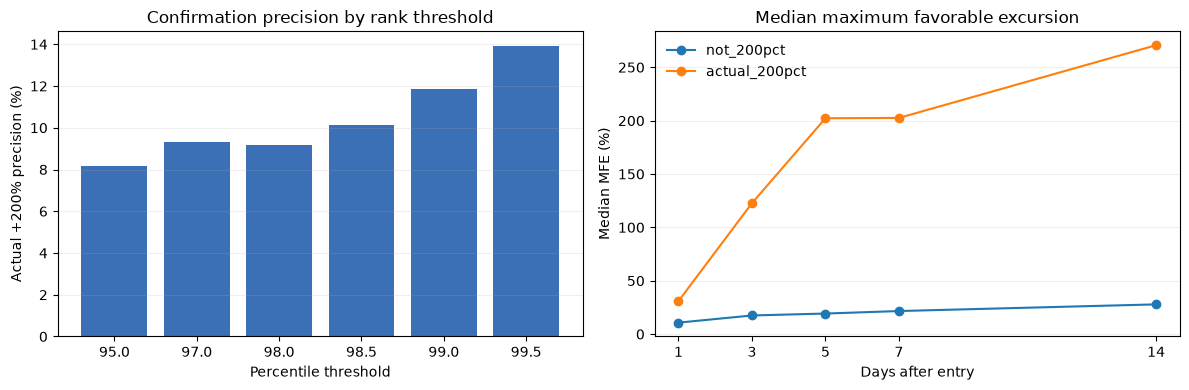

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar((100 * rank_confirmation['rank_threshold']).map(lambda x: f'{x:.1f}'), 100 * rank_confirmation['actual_200pct_precision'], color='#3B6FB6')
axes[0].set(title='Confirmation precision by rank threshold', xlabel='Percentile threshold', ylabel='Actual +200% precision (%)')
horizons = [1, 3, 5, 7, 14]
for _, row in path_summary.iterrows():
    axes[1].plot(horizons, [100 * row[f'median_mfe_{d}d'] for d in horizons], marker='o', label=row['cohort'])
axes[1].set(title='Median maximum favorable excursion', xlabel='Days after entry', ylabel='Median MFE (%)', xticks=horizons)
axes[1].legend(frameon=False)
for axis in axes: axis.grid(axis='y', alpha=.2)
plt.tight_layout(); plt.show()

## 24h sequential launch challenger

This extension separates identification from tradability. A secondary 24h path rule is selected on fully matured pre-confirmation rows, then measured on folds 3-6. Because the rule family followed earlier path exploration, it remains a forward-only challenger even when historical recognition gates pass.

In [8]:
sequence = json.loads((ROOT / 'sequential_strategy_decision.json').read_text(encoding='utf-8'))
simple_launch = json.loads((ROOT / 'simple_launch_strategy_decision.json').read_text(encoding='utf-8'))
launch_stop = json.loads((ROOT / 'launch_stop_strategy_decision.json').read_text(encoding='utf-8'))
launch_exit = json.loads((ROOT / 'launch_exit_state_decision.json').read_text(encoding='utf-8'))
simple_folds = pd.read_csv(ROOT / 'simple_launch_recognition_folds.csv')
exit_folds = pd.read_csv(ROOT / 'launch_exit_state_folds.csv')
pd.Series({
    '24h rule precision': simple_launch['recognition_confirmation']['selected_precision'],
    '24h rule event precision': simple_launch['event_recognition_confirmation']['selected_event_precision'],
    'winner retention': simple_launch['recognition_confirmation']['positive_retention'],
    'selected hard stop': launch_stop['selected_stop_width'],
    'selected exit': launch_exit['selected_exit_policy'],
    'exit expectancy': launch_exit['strategy_default_summary']['expectancy'],
    'exit profit factor': launch_exit['strategy_default_summary']['profit_factor'],
})

24h rule precision             0.254237
24h rule event precision       0.285714
winner retention               0.576923
selected hard stop                 0.25
selected exit               breakeven30
exit expectancy                0.101233
exit profit factor              1.83871
dtype: object

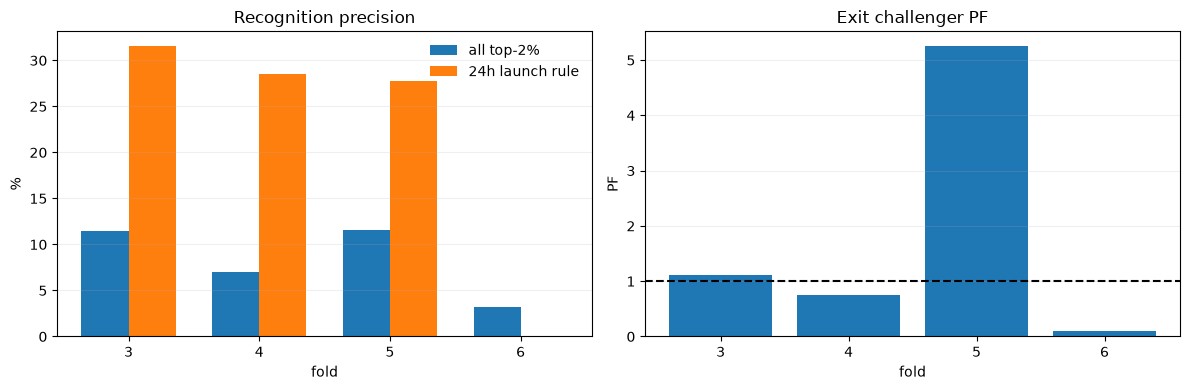

In [9]:
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(simple_folds)); width = .36
axes[0].bar(x-width/2, 100*simple_folds['base_precision'], width, label='all top-2%')
axes[0].bar(x+width/2, 100*simple_folds['selected_precision'], width, label='24h launch rule')
axes[0].set_xticks(x, simple_folds['fold'].astype(str)); axes[0].set(title='Recognition precision', xlabel='fold', ylabel='%')
axes[0].legend(frameon=False)
axes[1].bar(exit_folds['fold'].astype(str), exit_folds['profit_factor'])
axes[1].axhline(1, color='black', linestyle='--'); axes[1].set(title='Exit challenger PF', xlabel='fold', ylabel='PF')
for axis in axes: axis.grid(axis='y', alpha=.2)
plt.tight_layout(); plt.show()

## Post-launch entry-location falsification

Nine time-safe entry rules were calibrated before fold 3. Every delayed rule observes a completed 4h trigger and enters at the next open; its +200% label is recomputed from the actual entry. The calibration-selected 5% dip-and-reclaim rule failed folds 3-6, so the 24h confirmation open remains the paper observation baseline.

In [10]:
postlaunch = json.loads((ROOT / 'postlaunch_entry_decision.json').read_text(encoding='utf-8'))
postlaunch_cal = pd.read_csv(ROOT / 'postlaunch_entry_calibration.csv')
postlaunch_regimes = pd.read_csv(ROOT / 'postlaunch_regime_diagnostics.csv')
pd.DataFrame([
    {'entry': '24h confirmation open', **postlaunch['confirmation_recognition_baseline'], 'profit_factor': postlaunch['baseline_strategy_summary']['profit_factor']},
    {'entry': '5% dip + reclaim', **postlaunch['confirmation_recognition_selected'], 'profit_factor': postlaunch['strategy_default_summary']['profit_factor']},
])

,entry,entries,actual_200pct_entries,actual_200pct_precision,positive_retention_vs_launch_open,median_delay_hours,median_entry_return_vs_launch,profit_factor
0,24h confirmation open,59,8,0.135593,1.000,0.0,0.000000,1.838710
1,5% dip + reclaim,49,3,0.061224,0.375,12.0,-0.018177,1.090571


In [11]:
display(postlaunch_cal[['entry_rule','confirmed_entries','actual_200pct_precision','positive_retention','expectancy','profit_factor','selection_eligible']])
display(postlaunch_regimes)

,entry_rule,confirmed_entries,actual_200pct_precision,positive_retention,expectancy,profit_factor,selection_eligible
0,discount5_reclaim,19,0.263158,1.0,0.239527,4.746789,True
1,discount5_touch,20,0.250000,1.0,0.224371,3.275300,True
2,discount10_reclaim,13,0.307692,0.8,0.199172,3.207375,True
3,discount10_touch,14,0.285714,0.8,0.177065,2.707337,True
4,wait4h,28,0.178571,1.0,0.211969,3.318701,True
5,controlled_pullback5,15,0.200000,0.6,0.229046,5.054552,True
6,breakout6,11,0.181818,0.4,0.296975,4.914647,True
7,launch_open,28,0.178571,1.0,0.326296,6.475641,False
8,prelaunch_high_break,16,0.187500,0.6,0.064393,1.583154,False


,period,dimension,regime,entries,actual_200pct_entries,actual_200pct_precision
0,calibration,breadth_regime,broad,5,0,0.000000
1,calibration,breadth_regime,narrow,23,5,0.217391
2,confirmation,breadth_regime,broad,33,6,0.181818
3,confirmation,breadth_regime,narrow,26,2,0.076923
4,calibration,btc_trend_regime,bear,22,5,0.227273
5,calibration,btc_trend_regime,bull,6,0,0.000000
6,confirmation,btc_trend_regime,bear,37,4,0.108108
7,confirmation,btc_trend_regime,bull,22,4,0.181818
8,calibration,btc_vol_regime,highvol,15,2,0.133333
9,calibration,btc_vol_regime,lowvol,13,3,0.230769


## Prospective launch-time microstructure protocol

A separate read-only collector now runs at 12:05 Asia/Shanghai after the frozen 24h launch decision. Captures are valid only within 15 minutes and store timestamped order-book depth/impact, premium and funding, current and 1/4/24h OI, long/short ratios, and taker flow. Late or incomplete captures fail closed and cannot be backfilled. The first audit correctly rejected two stale confirmations (AKE and ESPORTS), so there are currently zero valid microstructure samples. Complete 30-day paths later receive immutable actual-funding labels for the frozen hard-25/BE30/half100/trail25 exit and one prospective close-stop counterfactual. None of these fields changes rank or permits trading.

## Frozen 8h continuation-utility paper gate

A separate time-isolated study directly predicted positive entry utility after 4/8/12/16/20/24 hours. Calibration selected the 8h checkpoint and top-30% model-score threshold. Historical confirmation produced 65 constrained trades with 16.50% expectancy, PF 2.50, and -4.28% maximum drawdown; 3/4 time folds and 5/6 market states had PF above one, while week and symbol bootstrap expectancy lower bounds were positive. Removing the largest contributing symbol left 10.69% expectancy. The model is frozen for forward OOS as `continuation-utility-8h-v1-frozen-2026-07-19`, remains secondary and read-only, and cannot override stage vetoes. Direct post-entry +200% identification still failed its ranking gate, so the new status is paper-entry candidate pending true OOS, not a validated extreme-run-up classifier.

## Multi-threshold recognition and right-tail exit frontier

The ordinal +50/+100/+150/+200% target improves confirmation AP and event retention but fails clustered uncertainty bounds. Early failure-to-launch exits are rejected. A +150% half-take-profit with a 30% trail improves exit point estimates, but paired incremental bootstrap intervals cross zero, so it is recorded only as a prospective counterfactual.

## 8h utility entry / 20h ordinal-intensity router

The pre-selected 20h ordinal score modestly increases pooled remaining +200% precision, but fails in two of four folds. Exiting low-intensity 8h entries at the 20h decision open changes confirmation expectancy from +16.50% to -1.06% and PF from 2.50 to 0.84. Paired week and symbol bootstrap upper bounds remain negative, so the router is strongly rejected.

## Profit-side blow-off exhaustion exit

After the frozen 8h entry, the calibration-selected policy waits for +150% before selling half, uses a 35% trail, and exits at the next 4h open after a doubled position prints a volume-backed upper-wick reversal. All four confirmation folds have PF above one and point estimates improve, but paired incremental week/symbol intervals still cross zero. It is therefore frozen only as a forward counterfactual.

## Static-tail versus wick-exit attribution

No policy is re-selected in this diagnostic. The pure volume-backed upper-wick timing effect is 1.99% per signal row and 1.26% per independent event, but row- and event-cluster intervals all cross zero. Widening the trail from 30% to 35% is uniformly harmful in confirmation. A derived 30%-trail plus wick policy has 18.50% expectancy and PF 2.68, but it was generated after inspecting confirmation and is therefore prospective-label-only.

## Entry execution after the frozen 8h utility score

Calibration selects a 5% discount followed by a positive higher-close reclaim, with entry at the next 4h open within a 24h trigger window. Confirmation filters 88 score-open signals to 54, raises row precision from 11.36% to 14.81%, and retains all five positive independent events. Event-cluster precision intervals are positive, but row-cluster intervals cross zero. The selected path has 14.97% expectancy and PF 2.28; absolute and paired trade intervals cross zero. It is prospective-only and does not replace score-open entry.

## Full entry-rule frontier diagnostic

The six-bar close breakout has 28.57% row precision and improves over score-open in all four confirmation folds, but it had zero calibration positives, misses catalog-level BH significance, and its event-cluster intervals cross zero. More importantly, waiting for the breakout reduces matched trade return by 17.80%; both paired upper bounds are negative. Breakout is therefore a possible after-entry hold/recognition annotation, not a buy trigger. No additional forward buy rule is added.

## Breakout-confirmed hold router

The frozen 8h entry remains unchanged. A completed six-bar breakout within 24 hours switches only profit-side management at the following 4h open: +150% half-sale, 30% trailing remainder, and a next-open volume-backed upper-wick exhaustion exit after the trade has doubled. Historical expectancy is 19.65%, PF 2.79; paired all-row and independent-event gains are 3.00% and 2.31%. All four week/symbol lower bounds are positive, but the router was discovered after confirmation inspection and is frozen only as a prospective counterfactual. It does not change the primary exit or authorize trading.

## Risk-neutral breakout add allocation

The total planned position and maximum risk remain fixed. Calibration selects zero reserve: every 10%/25%/50% breakout-add allocation has a negative paired increment in all three calibration windows. Confirmation agrees. Reserving 10% lowers expectancy from 19.65% to 18.38% even though PF increases from 2.79 to 2.83; the apparent risk improvement comes from lower average deployment, not additional alpha. The result retains the full planned 8h entry and rejects breakout pyramiding. Breakout remains a profit-side hold/exit router only.

## 8h taker-buy-share identification annotation

A semantic filter requiring the first two completed 4h bars to have taker buy quote share of at least 50% retains 9/10 confirmation +200% rows and raises precision from 11.36% to 18.75%. Row-level week and symbol lower bounds are positive, but independent-event lower bounds cross zero. The filtered frozen-exit portfolio has 18.68% expectancy and PF 2.75; combining it with the prospective breakout hold router reaches 22.13% and PF 3.07, but fold 6 is negative and the symbol-cluster absolute-return lower bound remains below zero. The field is therefore recorded prospectively without changing rank, stage veto, paper eligibility, or trading authority.

## Strategy frontier falsifications

Three additional hypotheses were time-isolated: staged probe/add allocation, close-confirmed initial stops with a catastrophic floor, and contract listing age as an exchange-lifecycle ranking factor. Calibration retained zero probe, the 25% hard stop, and the original price ranking.

In [12]:
staged = json.loads((ROOT / 'staged_entry_decision.json').read_text(encoding='utf-8'))
hybrid = json.loads((ROOT / 'hybrid_stop_decision.json').read_text(encoding='utf-8'))
lifecycle = json.loads((ROOT / 'lifecycle_factor_decision.json').read_text(encoding='utf-8'))
pd.Series({
    'selected probe fraction': staged['selected_probe_fraction'],
    'selected initial stop': hybrid['selected_policy'],
    'price top2 precision': lifecycle['price_pooled']['top_2pct_precision'],
    'price+age top2 precision': lifecycle['price_plus_age_pooled']['top_2pct_precision'],
    'price event capture': lifecycle['price_event_capture']['captured'],
    'price+age event capture': lifecycle['price_plus_age_event_capture']['captured'],
})

selected probe fraction                 0.0
selected initial stop       baseline_hard25
price top2 precision               0.094025
price+age top2 precision           0.082762
price event capture                      39
price+age event capture                  29
dtype: object

In [13]:
display(pd.read_csv(ROOT / 'staged_entry_calibration.csv'))
display(pd.read_csv(ROOT / 'hybrid_stop_calibration.csv'))
display(pd.read_csv(ROOT / 'lifecycle_factor_fold_metrics.csv'))

,probe_fraction,add_fraction_after_launch,trades,launch_confirmed_trade_share,expectancy,profit_factor,max_drawdown,folds,fold_expectancy_mean,fold_expectancy_std,leave_largest_expectancy,largest_positive_pnl_share,selection_score,selection_eligible
0,0.00,1.00,26,1.00000,0.326296,6.475641,-0.022613,3,0.319740,0.015509,0.286679,0.133843,0.311986,True
1,0.10,0.90,125,0.15200,0.037680,3.346437,-0.024141,3,0.025457,0.034617,0.028397,0.183075,0.008148,True
2,0.25,0.75,125,0.15200,0.030279,2.212581,-0.028127,3,0.017174,0.037785,0.022485,0.148644,-0.001719,True
3,0.50,0.50,125,0.15200,0.017944,1.450584,-0.034669,3,0.003369,0.043260,0.010080,0.135918,-0.018262,True
4,0.75,0.25,125,0.15200,0.005610,1.102595,-0.047000,3,-0.010437,0.048907,-0.002502,0.133513,-0.034890,False
5,1.00,0.00,126,0.15873,-0.006683,0.903182,-0.069471,3,-0.024060,0.054654,-0.017157,0.163879,-0.051387,False


,policy,stop_mode,risk_width,catastrophic_stop,close_stop,close_stop_bars,trades,expectancy,profit_factor,max_drawdown,folds,fold_expectancy_mean,fold_expectancy_std,leave_largest_expectancy,largest_positive_pnl_share,selection_score,selection_eligible
0,baseline_hard25,hard,0.25,0.25,NaN,NaN,26,0.326296,6.475641,-0.022613,3,0.319740,0.015509,0.286679,0.133843,0.311986,True
1,cat40_close15x2,hybrid,0.40,0.40,0.15,2.0,26,0.311210,6.595004,-0.012689,3,0.314360,0.011931,0.270989,0.139446,0.308395,True
2,cat40_close25x1,hybrid,0.40,0.40,0.25,1.0,26,0.321157,5.992825,-0.015262,3,0.313232,0.018853,0.281334,0.133082,0.303805,True
3,cat50_close20x2,hybrid,0.50,0.50,0.20,2.0,26,0.301957,5.747484,-0.010550,3,0.305628,0.014715,0.261366,0.139864,0.298271,True
4,cat40_close20x1,hybrid,0.40,0.40,0.20,1.0,26,0.302165,5.766513,-0.013393,3,0.304460,0.013267,0.261582,0.140179,0.297827,True
5,cat50_close20x1,hybrid,0.50,0.50,0.20,1.0,26,0.302165,5.766513,-0.010765,3,0.304460,0.013267,0.261582,0.139865,0.297827,True
6,cat35_close15x1,hybrid,0.35,0.35,0.15,1.0,27,0.271891,5.524557,-0.014514,3,0.284160,0.033048,0.231705,0.147597,0.267637,True
7,cat40_close15x1,hybrid,0.40,0.40,0.15,1.0,27,0.271891,5.524557,-0.012745,3,0.284160,0.033048,0.231705,0.147518,0.267637,True


,fold,train_start,train_end,test_start,test_end,rows,positives,price_average_precision,age_average_precision,combo_average_precision,price_top2_precision,age_top2_precision,combo_top2_precision,price_top2_lift,age_top2_lift,combo_top2_lift,ap_improved,lift_improved
0,0,2025-06-13 00:00:00+00:00,2025-12-09 00:00:00+00:00,2025-12-24 00:00:00+00:00,2026-01-22 00:00:00+00:00,14366,103,0.072464,0.015848,0.029053,0.103333,0.000000,0.053333,14.412492,0.000000,7.438706,False,False
1,1,2025-06-13 00:00:00+00:00,2026-01-08 00:00:00+00:00,2026-01-23 00:00:00+00:00,2026-02-21 00:00:00+00:00,14797,79,0.037466,0.016223,0.023988,0.043333,0.040000,0.046667,8.116498,7.492152,8.740844,False,True
2,2,2025-06-13 00:00:00+00:00,2026-02-07 00:00:00+00:00,2026-02-22 00:00:00+00:00,2026-03-23 00:00:00+00:00,14998,81,0.018822,0.006222,0.011019,0.043750,0.000000,0.031250,8.100772,0.000000,5.786265,False,False
3,3,2025-06-13 00:00:00+00:00,2026-03-09 00:00:00+00:00,2026-03-24 00:00:00+00:00,2026-04-22 00:00:00+00:00,15177,330,0.083338,0.066165,0.090753,0.142424,0.139394,0.154545,6.550220,6.410854,7.107686,True,True
4,4,2025-06-13 00:00:00+00:00,2026-04-08 00:00:00+00:00,2026-04-23 00:00:00+00:00,2026-05-22 00:00:00+00:00,15358,145,0.060872,0.018068,0.047425,0.106061,0.048485,0.072727,11.233647,5.135381,7.703072,False,False
5,5,2025-06-13 00:00:00+00:00,2026-05-08 00:00:00+00:00,2026-05-23 00:00:00+00:00,2026-06-21 00:00:00+00:00,15503,221,0.104613,0.030440,0.087797,0.154545,0.048485,0.163636,10.841259,3.401179,11.478980,False,True
6,6,2025-06-13 00:00:00+00:00,2026-06-07 00:00:00+00:00,2026-06-22 00:00:00+00:00,2026-07-03 00:00:00+00:00,6258,56,0.019430,0.010911,0.017194,0.007576,0.007576,0.000000,0.846591,0.846591,0.000000,False,False


## Taker-flow independence and breakout full-runner audit

The fixed 50% taker-buy-share annotation is directionally robust from 48% to 51%, but matching on both early return and path efficiency gives a one-sided permutation p-value of 0.069. It is not independently identified and remains rank-neutral. All six full-position runner exits fail the 14-day calibration gate. A narrower partial-sale test selects 75% in calibration but reverses in confirmation, where 25% is best; the stable 50% rule is retained. Confirmation-only winners are counterexamples, not promotions.

In [14]:
display(pd.read_csv(ROOT / 'utility_taker_flow_robustness_definitions.csv'))
display(pd.read_csv(ROOT / 'utility_taker_flow_price_matched_permutation.csv'))
display(pd.read_csv(ROOT / 'utility_breakout_runner_calibration.csv'))
display(pd.read_csv(ROOT / 'utility_breakout_runner_confirmation.csv'))
display(pd.read_csv(ROOT / 'utility_breakout_partial_fraction_calibration.csv'))
display(pd.read_csv(ROOT / 'utility_breakout_partial_fraction_confirmation.csv'))

,period,definition,base_rows,base_positives,base_precision,selected_rows,selected_positives,selected_precision,precision_increment,positive_retention,utility_expectancy_14d,base_events,base_positive_events,selected_events,selected_positive_events,selected_event_precision
0,calibration,mean_ge_47pct,42,3,0.071429,37,3,0.081081,0.009653,1.000000,0.128320,33,3,31,3,0.096774
1,calibration,mean_ge_48pct,42,3,0.071429,31,3,0.096774,0.025346,1.000000,0.120978,33,3,25,3,0.120000
2,calibration,mean_ge_49pct,42,3,0.071429,26,3,0.115385,0.043956,1.000000,0.099054,33,3,21,3,0.142857
3,calibration,mean_ge_50pct,42,3,0.071429,21,3,0.142857,0.071429,1.000000,0.081322,33,3,17,3,0.176471
4,calibration,mean_ge_51pct,42,3,0.071429,12,2,0.166667,0.095238,0.666667,0.073613,33,3,12,2,0.166667
5,calibration,mean_ge_52pct,42,3,0.071429,4,0,0.000000,-0.071429,0.000000,0.007358,33,3,4,0,0.000000
6,calibration,both_bars_ge_50pct,42,3,0.071429,15,3,0.200000,0.128571,1.000000,0.064152,33,3,14,3,0.214286
7,calibration,last_bar_ge_50pct,42,3,0.071429,20,3,0.150000,0.078571,1.000000,0.142141,33,3,17,3,0.176471
8,calibration,first_bar_ge_50pct,42,3,0.071429,23,3,0.130435,0.059006,1.000000,0.124031,33,3,19,3,0.157895
9,calibration,mean_ge_50pct_and_nondeclining,42,3,0.071429,10,1,0.100000,0.028571,0.333333,0.027984,33,3,9,1,0.111111


,schema,match_features,rows,strata,observed_precision_increment,permutations,one_sided_p,null_median,null_upper_95pct
0,return_only,['early_close_return'],88,12,0.073864,5000,0.045191,0.011364,0.053030
1,return_and_efficiency,"['early_close_return', 'early_path_efficiency']",88,28,0.073864,5000,0.069186,0.032197,0.073864
2,return_and_model_score,"['early_close_return', 'continuation_score']",88,36,0.073864,5000,0.013397,0.011364,0.053030


,policy,trades,expectancy,median_return,win_rate,profit_factor,cvar_5pct,mean_mfe,mean_mae,funding_coverage,...,gate_pass,take_profit_exit_rate,trailing_exit_rate,hard_stop_exit_rate,median_holding_days,paired_increment_mean,event_increment_mean,positive_split_share,fold_profit_factor_gt1_share,selection_eligible
0,breakout6_half150_trail30_wick,30,0.047654,-0.002571,0.3,1.599385,-0.252548,0.455469,-0.165654,0.3,...,False,0.0,0.033333,0.233333,7.25,0.000000,0.000000,0.0,0.5,False
1,breakout6_full_runner_a100_t25_wick,30,0.029709,-0.002571,0.3,1.373677,-0.252548,0.455469,-0.165654,0.3,...,False,0.0,0.033333,0.233333,7.25,-0.028885,-0.016314,0.0,0.5,False
2,breakout6_full_runner_a100_t30_wick,30,0.029709,-0.002571,0.3,1.373677,-0.252548,0.455469,-0.165654,0.3,...,False,0.0,0.033333,0.233333,7.25,-0.019480,-0.016314,0.0,0.5,False
3,breakout6_full_runner_a100_t35_wick,30,0.029523,-0.002571,0.3,1.371336,-0.252548,0.455469,-0.165654,0.3,...,False,0.0,0.033333,0.233333,7.25,-0.022911,-0.016483,0.0,0.5,False
4,breakout6_full_runner_a150_t25_wick,30,0.029709,-0.002571,0.3,1.373677,-0.252548,0.455469,-0.165654,0.3,...,False,0.0,0.033333,0.233333,7.25,-0.016182,-0.016314,0.0,0.5,False
5,breakout6_full_runner_a150_t30_wick,30,0.029709,-0.002571,0.3,1.373677,-0.252548,0.455469,-0.165654,0.3,...,False,0.0,0.033333,0.233333,7.25,-0.019480,-0.016314,0.0,0.5,False
6,breakout6_full_runner_a150_t35_wick,30,0.029523,-0.002571,0.3,1.371336,-0.252548,0.455469,-0.165654,0.3,...,False,0.0,0.033333,0.233333,7.25,-0.022911,-0.016483,0.0,0.5,False


,trades,expectancy,median_return,win_rate,profit_factor,cvar_5pct,mean_mfe,mean_mae,funding_coverage,total_return_on_initial_equity,...,median_notional_usd,maximum_concurrent_positions_constraint,maximum_gross_exposure_constraint,gate_pass,take_profit_exit_rate,trailing_exit_rate,hard_stop_exit_rate,median_holding_days,policy,slippage_bps_each_side
0,65,0.196496,-0.0015,0.353846,2.792021,-0.258544,0.658648,-0.195918,0.307692,0.274021,...,2247.635510,10,0.5,True,0.0,0.200000,0.415385,6.000000,breakout6_half150_trail30_wick,5.0
1,65,0.184732,-0.0015,0.353846,2.684737,-0.258544,0.611710,-0.195918,0.307692,0.255699,...,2226.548133,10,0.5,True,0.0,0.215385,0.415385,5.833333,breakout6_full_runner_a100_t25_wick,5.0
2,65,0.208162,-0.0015,0.353846,2.898413,-0.258544,0.655408,-0.195918,0.307692,0.291937,...,2244.142743,10,0.5,True,0.0,0.200000,0.415385,5.833333,breakout6_full_runner_a100_t30_wick,5.0
3,65,0.199915,-0.0015,0.353846,2.823203,-0.258544,0.655408,-0.195918,0.307692,0.279471,...,2222.526599,10,0.5,True,0.0,0.200000,0.415385,5.833333,breakout6_full_runner_a100_t35_wick,5.0
4,65,0.187049,-0.0015,0.353846,2.705863,-0.258544,0.614950,-0.195918,0.307692,0.259278,...,2232.883482,10,0.5,True,0.0,0.215385,0.415385,6.000000,breakout6_full_runner_a150_t25_wick,5.0
5,65,0.210326,-0.0015,0.353846,2.918146,-0.258544,0.658648,-0.195918,0.307692,0.295342,...,2250.046034,10,0.5,True,0.0,0.200000,0.415385,6.000000,breakout6_full_runner_a150_t30_wick,5.0
6,65,0.201917,-0.0015,0.353846,2.841460,-0.258544,0.658648,-0.195918,0.307692,0.282612,...,2227.973570,10,0.5,True,0.0,0.200000,0.415385,6.000000,breakout6_full_runner_a150_t35_wick,5.0
7,65,0.191077,-0.0025,0.353846,2.675301,-0.259294,0.661231,-0.200328,0.307692,0.265687,...,2235.000468,10,0.5,True,0.0,0.200000,0.430769,6.333333,breakout6_half150_trail30_wick,15.0
8,65,0.179241,-0.0025,0.353846,2.571527,-0.259294,0.614340,-0.200328,0.307692,0.247315,...,2220.728006,10,0.5,True,0.0,0.215385,0.430769,6.000000,breakout6_full_runner_a100_t25_wick,15.0
9,65,0.202623,-0.0025,0.353846,2.776539,-0.259294,0.657994,-0.200328,0.307692,0.283300,...,2238.252310,10,0.5,True,0.0,0.200000,0.430769,6.000000,breakout6_full_runner_a100_t30_wick,15.0


,policy,trades,expectancy,median_return,win_rate,profit_factor,cvar_5pct,mean_mfe,mean_mae,funding_coverage,...,hard_stop_exit_rate,median_holding_days,paired_increment_mean,event_increment_mean,positive_split_share,fold_profit_factor_gt1_share,selection_eligible,split_increment_means,partial_fraction,slippage_bps_each_side
0,breakout6_sell25_at150_trail30_wick,30,0.038682,-0.002571,0.3,1.486531,-0.252548,0.455469,-0.165654,0.3,...,0.233333,7.25,-0.00974,-0.008157,0.000000,0.5,False,cal_1:0|cal_2:-0.0093271179012|cal_3:-0.013458...,0.25,5.0
1,breakout6_sell50_at150_trail30_wick,30,0.047654,-0.002571,0.3,1.599385,-0.252548,0.455469,-0.165654,0.3,...,0.233333,7.25,0.00000,0.000000,0.000000,0.5,False,cal_1:0|cal_2:0|cal_3:0,0.50,5.0
2,breakout6_sell75_at150_trail30_wick,30,0.056626,-0.002571,0.3,1.712239,-0.252548,0.455469,-0.165654,0.3,...,0.233333,7.25,0.00974,0.008157,0.666667,0.5,True,cal_1:0|cal_2:0.0093271179012|cal_3:0.01345864...,0.75,5.0


,policy,trades,expectancy,median_return,win_rate,profit_factor,cvar_5pct,mean_mfe,mean_mae,funding_coverage,...,hard_stop_exit_rate,median_holding_days,paired_increment_mean,event_increment_mean,positive_split_share,fold_profit_factor_gt1_share,selection_eligible,split_increment_means,partial_fraction,slippage_bps_each_side
0,breakout6_sell25_at150_trail30_wick,65,0.203411,-0.0015,0.353846,2.855083,-0.258544,0.658648,-0.195918,0.307692,...,0.415385,6.000000,0.004737,0.002130,0.75,1.00,True,fold_3:0.0117980011991|fold_4:-0.0116700352509...,0.25,5.0
1,breakout6_sell50_at150_trail30_wick,65,0.196496,-0.0015,0.353846,2.792021,-0.258544,0.658648,-0.195918,0.307692,...,0.415385,6.000000,0.000000,0.000000,0.00,1.00,False,fold_3:0|fold_4:0|fold_5:0|fold_6:0,0.50,5.0
2,breakout6_sell75_at150_trail30_wick,65,0.189581,-0.0015,0.353846,2.728958,-0.258544,0.658648,-0.195918,0.307692,...,0.415385,6.000000,-0.004737,-0.002130,0.25,1.00,False,fold_3:-0.0117980011991|fold_4:0.0116700352509...,0.75,5.0
3,breakout6_sell25_at150_trail30_wick,65,0.197930,-0.0025,0.353846,2.735386,-0.259294,0.661231,-0.200328,0.307692,...,0.430769,6.333333,0.004684,0.002089,0.75,0.75,True,fold_3:0.0117503502687|fold_4:-0.0117187318179...,0.25,15.0
4,breakout6_sell50_at150_trail30_wick,65,0.191077,-0.0025,0.353846,2.675301,-0.259294,0.661231,-0.200328,0.307692,...,0.430769,6.333333,0.000000,0.000000,0.00,1.00,False,fold_3:0|fold_4:0|fold_5:0|fold_6:0,0.50,15.0
5,breakout6_sell75_at150_trail30_wick,65,0.184224,-0.0025,0.353846,2.615216,-0.259294,0.661231,-0.200328,0.307692,...,0.430769,6.333333,-0.004684,-0.002089,0.25,1.00,False,fold_3:-0.0117503502687|fold_4:0.0117187318179...,0.75,15.0
6,breakout6_sell25_at150_trail30_wick,65,0.199098,-0.0040,0.338462,2.732541,-0.260419,0.668428,-0.201426,0.307692,...,0.430769,6.333333,0.004607,0.002027,0.75,0.75,True,fold_3:0.0116791419042|fold_4:-0.0117913249787...,0.25,30.0
7,breakout6_sell50_at150_trail30_wick,65,0.192337,-0.0040,0.338462,2.673710,-0.260419,0.668428,-0.201426,0.307692,...,0.430769,6.333333,0.000000,0.000000,0.00,1.00,False,fold_3:0|fold_4:0|fold_5:0|fold_6:0,0.50,30.0
8,breakout6_sell75_at150_trail30_wick,65,0.185577,-0.0040,0.338462,2.614880,-0.260419,0.668428,-0.201426,0.307692,...,0.430769,6.333333,-0.004607,-0.002027,0.25,1.00,False,fold_3:-0.0116791419042|fold_4:0.0117913249787...,0.75,30.0


### Regime-router and forward-monitor audit

Only 3 calibration signals and 6 confirmation signals change outcome when the partial-sale fraction changes. The calibration-selected state router therefore falls back to the fixed 50% rule and no forward field changes. The immutable monitor contains snapshots for 2026-07-18, 2026-07-19, but is missing 2026-07-20, 2026-07-21; the late live-data dry-run passed data quality but is explicitly excluded from true OOS performance.

In [15]:
display(pd.read_csv(ROOT / 'utility_regime_partial_router_calibration.csv'))
display(pd.read_csv(ROOT / 'utility_regime_partial_router_confirmation.csv'))
display(pd.read_csv(ROOT / 'utility_regime_partial_fraction_segments.csv'))
display(json.loads((ROOT / 'forward_monitor_operational_audit_2026-07-21.json').read_text(encoding='utf-8')))

,route,trades,expectancy,median_return,win_rate,profit_factor,cvar_5pct,mean_mfe,mean_mae,funding_coverage,...,take_profit_exit_rate,trailing_exit_rate,hard_stop_exit_rate,median_holding_days,affected_rows,paired_increment_mean,affected_increment_mean,positive_split_share,split_increment_means,selection_eligible
0,baseline_sell50,30,0.047654,-0.002571,0.3,1.599385,-0.252548,0.455469,-0.165654,0.3,...,0.0,0.033333,0.233333,7.25,0,0.00000,0.00000,0.000000,cal_1:0|cal_2:0|cal_3:0,False
1,semantic_vol_high25_low75,30,0.038682,-0.002571,0.3,1.486531,-0.252548,0.455469,-0.165654,0.3,...,0.0,0.033333,0.233333,7.25,3,-0.00974,-0.13636,0.000000,cal_1:0|cal_2:-0.0093271179012|cal_3:-0.013458...,False
2,calibration_vol_high75_low50,30,0.056626,-0.002571,0.3,1.712239,-0.252548,0.455469,-0.165654,0.3,...,0.0,0.033333,0.233333,7.25,3,0.00974,0.13636,0.666667,cal_1:0|cal_2:0.0093271179012|cal_3:0.01345864...,False
3,semantic_risk_bull25_bear_narrow75,30,0.047654,-0.002571,0.3,1.599385,-0.252548,0.455469,-0.165654,0.3,...,0.0,0.033333,0.233333,7.25,0,0.00000,0.00000,0.000000,cal_1:0|cal_2:0|cal_3:0,False
4,calibration_market_state_min5,30,0.047654,-0.002571,0.3,1.599385,-0.252548,0.455469,-0.165654,0.3,...,0.0,0.033333,0.233333,7.25,0,0.00000,0.00000,0.000000,cal_1:0|cal_2:0|cal_3:0,False


,route,trades,expectancy,median_return,win_rate,profit_factor,cvar_5pct,mean_mfe,mean_mae,funding_coverage,...,trailing_exit_rate,hard_stop_exit_rate,median_holding_days,affected_rows,paired_increment_mean,affected_increment_mean,positive_split_share,split_increment_means,selection_eligible,slippage_bps_each_side
0,baseline_sell50,65,0.196496,-0.0015,0.353846,2.792021,-0.258544,0.658648,-0.195918,0.307692,...,0.2,0.415385,6.000000,0,0.000000,0.000000,0.00,fold_3:0|fold_4:0|fold_5:0|fold_6:0,False,5.0
1,semantic_vol_high25_low75,65,0.205233,-0.0015,0.353846,2.871699,-0.258544,0.658648,-0.195918,0.307692,...,0.2,0.415385,6.000000,6,0.006824,0.100090,0.75,fold_3:0.0117980011991|fold_4:0.00275709249623...,True,5.0
2,calibration_vol_high75_low50,65,0.188670,-0.0015,0.353846,2.720650,-0.258544,0.658648,-0.195918,0.307692,...,0.2,0.415385,6.000000,3,-0.005780,-0.169559,0.25,fold_3:-0.0117980011991|fold_4:0.0044564713773...,False,5.0
3,semantic_risk_bull25_bear_narrow75,65,0.190688,-0.0015,0.353846,2.739053,-0.258544,0.658648,-0.195918,0.307692,...,0.2,0.415385,6.000000,6,-0.004661,-0.068360,0.25,fold_3:0.0117980011991|fold_4:-0.0116700352509...,False,5.0
4,calibration_market_state_min5,65,0.196496,-0.0015,0.353846,2.792021,-0.258544,0.658648,-0.195918,0.307692,...,0.2,0.415385,6.000000,0,0.000000,0.000000,0.00,fold_3:0|fold_4:0|fold_5:0|fold_6:0,False,5.0
5,baseline_sell50,65,0.191077,-0.0025,0.353846,2.675301,-0.259294,0.661231,-0.200328,0.307692,...,0.2,0.430769,6.333333,0,0.000000,0.000000,0.00,fold_3:0|fold_4:0|fold_5:0|fold_6:0,False,15.0
6,semantic_vol_high25_low75,65,0.199786,-0.0025,0.353846,2.751665,-0.259294,0.661231,-0.200328,0.307692,...,0.2,0.430769,6.333333,6,0.006811,0.099889,0.75,fold_3:0.0117503502687|fold_4:0.00277567398518...,True,15.0
7,calibration_vol_high75_low50,65,0.183295,-0.0025,0.353846,2.607077,-0.259294,0.661231,-0.200328,0.307692,...,0.2,0.430769,6.333333,3,-0.005748,-0.168595,0.25,fold_3:-0.0117503502687|fold_4:0.0044715289163...,False,15.0
8,semantic_risk_bull25_bear_narrow75,65,0.185271,-0.0025,0.353846,2.624397,-0.259294,0.661231,-0.200328,0.307692,...,0.2,0.430769,6.333333,6,-0.004666,-0.068432,0.25,fold_3:0.0117503502687|fold_4:-0.0117187318179...,False,15.0
9,calibration_market_state_min5,65,0.191077,-0.0025,0.353846,2.675301,-0.259294,0.661231,-0.200328,0.307692,...,0.2,0.430769,6.333333,0,0.000000,0.000000,0.00,fold_3:0|fold_4:0|fold_5:0|fold_6:0,False,15.0


,dimension,period,segment,fraction,rows,affected_rows,mean_delta,affected_mean_delta
0,btc_trend_regime,calibration,bear,0.25,35,3,-0.011688,-0.136360
1,btc_trend_regime,calibration,bear,0.75,35,3,0.011688,0.136360
2,btc_trend_regime,calibration,bull,0.25,7,0,0.000000,NaN
3,btc_trend_regime,calibration,bull,0.75,7,0,0.000000,NaN
4,btc_trend_regime,confirmation,bear,0.25,53,2,0.007802,0.206744
5,btc_trend_regime,confirmation,bear,0.75,53,2,-0.007802,-0.206744
6,btc_trend_regime,confirmation,bull,0.25,35,4,0.000095,0.000832
7,btc_trend_regime,confirmation,bull,0.75,35,4,-0.000095,-0.000832
8,btc_vol_regime,calibration,highvol,0.25,42,3,-0.009740,-0.136360
9,btc_vol_regime,calibration,highvol,0.75,42,3,0.009740,0.136360


{'audit_generated_at_utc': '2026-07-21T16:07:20.8199637+00:00',
 'scheduled_clock': '08:20 Asia/Shanghai',
 'audit_through_local_date': '2026-07-21',
 'immutable_snapshot_dates_present': ['2026-07-18', '2026-07-19'],
 'immutable_snapshot_dates_missing': ['2026-07-20', '2026-07-21'],
 'punctual_snapshot_dates': ['2026-07-19'],
 'late_research_snapshot_dates': ['2026-07-18'],
 'automation_status': 'ACTIVE',
 'automation_last_recorded_run_local': '2026-07-19T08:23:44+08:00',
 'mature_utility_observations': 0,
 'mature_launch_microstructure_observations': 0,
 'sequence_24h_observations': 6,
 'live_public_data_diagnostic': {'requested_as_of_utc': '2026-07-21T00:20:00+00:00',
  'executed_after_schedule': True,
  'dry_run': True,
  'snapshot_written': False,
  'audit_passed': True,
  'universe_count': 527,
  'previous_universe_count': 527,
  'universe_coverage_vs_previous': 1.0,
  'valid_price_feature_count': 527,
  'valid_price_feature_rate': 1.0,
  'feature_date_utc': '2026-07-20T00:00:00+0